In [2]:
import numpy as np
import pandas as pd

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score

In [3]:
print("Loading Data.......")

data = pd.read_csv('concrete_data.csv')

print("Data Loaded Successfully")

Loading Data.......
Data Loaded Successfully


In [4]:
data.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [6]:
data.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [7]:
data.duplicated().sum()

np.int64(25)

In [8]:
data.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [9]:
X = data.drop(columns=['Strength'])
y = data.iloc[:, -1]

In [148]:
X

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360
...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28


In [111]:
y

0       79.99
1       61.89
2       40.27
3       41.05
4       44.30
        ...  
1025    44.28
1026    31.18
1027    23.70
1028    32.77
1029    32.40
Name: Strength, Length: 1030, dtype: float64

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [11]:
X_train

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
335,275.1,0.0,121.4,159.5,9.9,1053.6,777.5,14
409,167.4,129.9,128.6,175.5,7.8,1006.3,746.6,3
892,273.0,0.0,90.0,199.0,11.0,931.0,762.0,28
398,160.0,128.0,122.0,182.0,6.4,824.0,879.0,28
986,272.8,105.1,81.8,209.7,9.0,904.0,679.7,28
...,...,...,...,...,...,...,...,...
888,153.0,145.0,0.0,178.0,8.0,1000.0,822.0,28
691,212.0,141.3,0.0,203.5,0.0,973.4,750.0,3
497,355.0,19.0,97.0,145.0,13.1,967.0,871.0,28
94,313.3,262.2,0.0,175.5,8.6,1046.9,611.8,7


In [114]:
X_test

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
903,155.0,0.0,143.0,193.0,9.0,1047.0,697.0,28
698,203.5,305.3,0.0,203.5,0.0,963.4,630.0,28
588,186.2,124.1,0.0,185.7,0.0,1083.4,764.3,7
188,222.4,0.0,96.7,189.3,4.5,967.1,870.3,100
94,313.3,262.2,0.0,175.5,8.6,1046.9,611.8,7
...,...,...,...,...,...,...,...,...
986,272.8,105.1,81.8,209.7,9.0,904.0,679.7,28
504,491.0,26.0,123.0,201.0,3.9,822.0,699.0,3
713,157.0,236.0,0.0,192.0,0.0,935.4,781.2,3
322,249.1,0.0,98.8,158.1,12.8,987.8,889.0,56


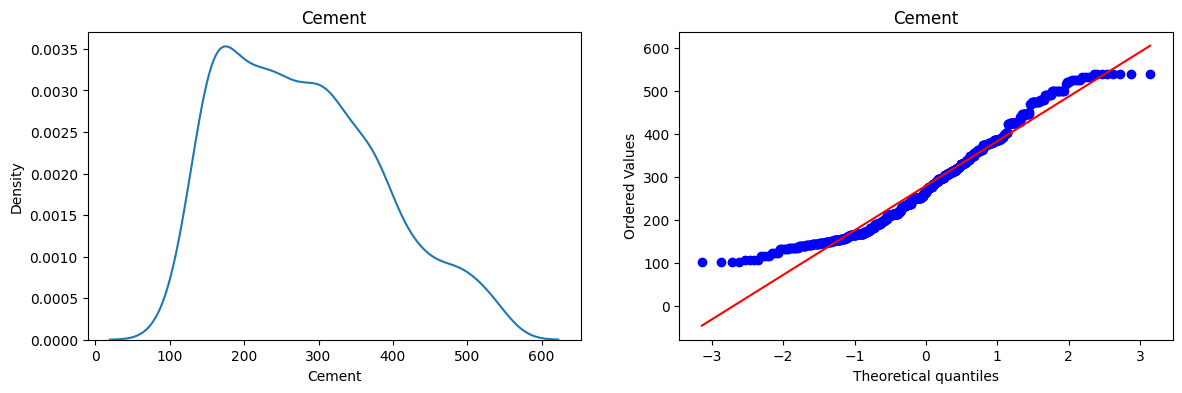

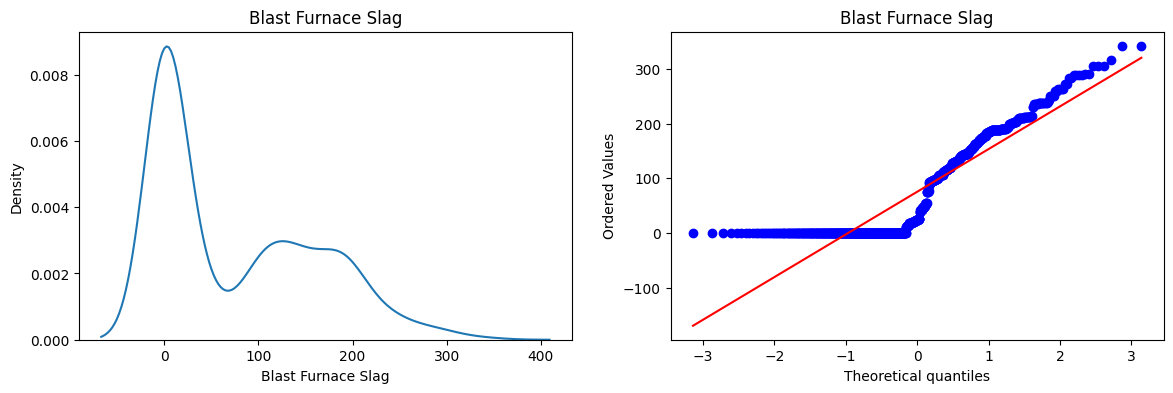

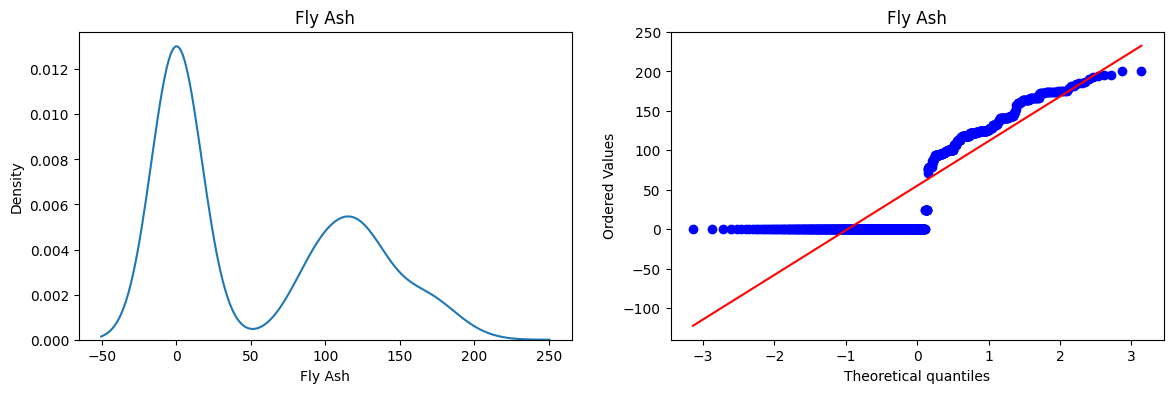

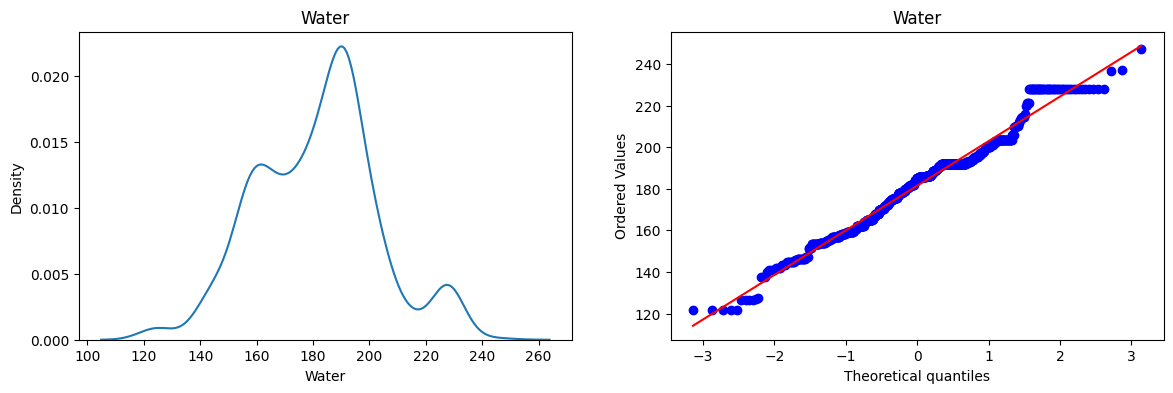

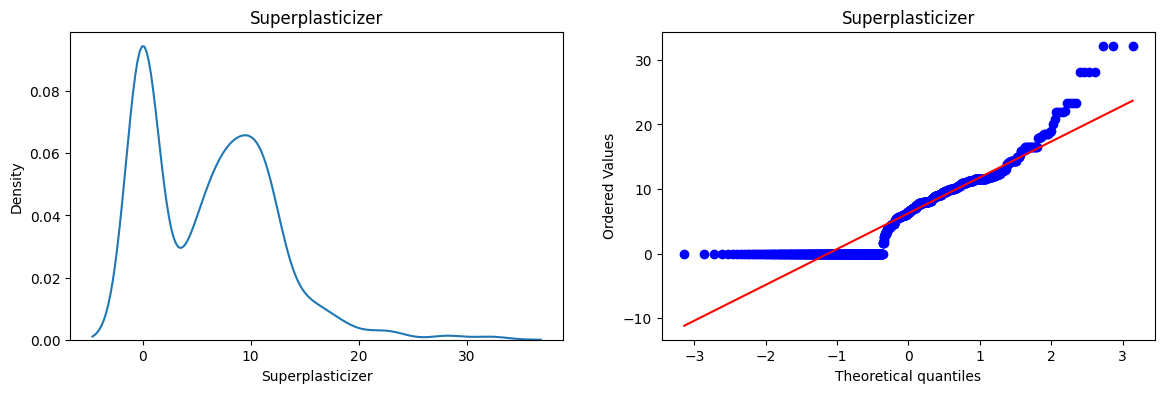

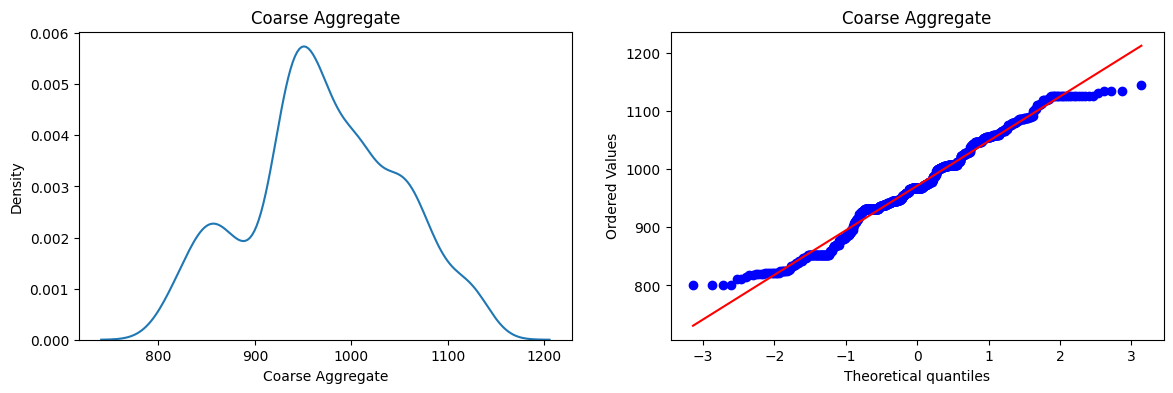

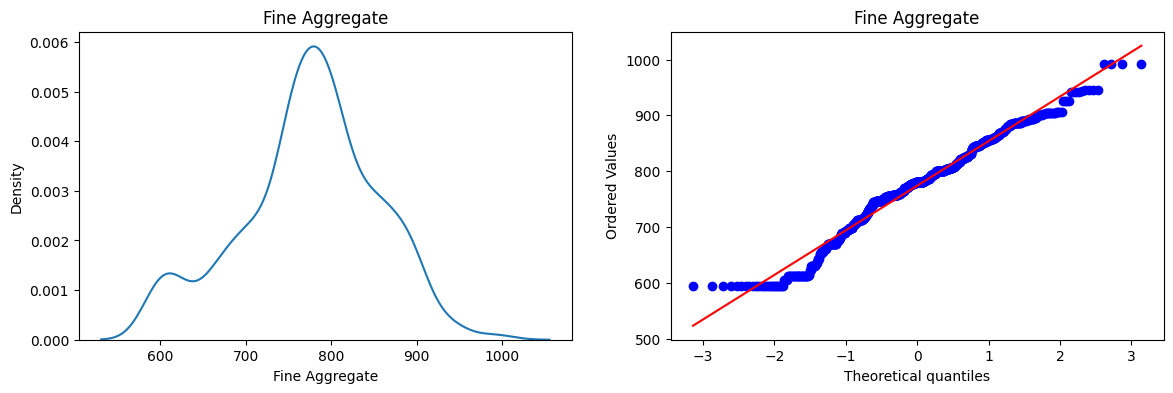

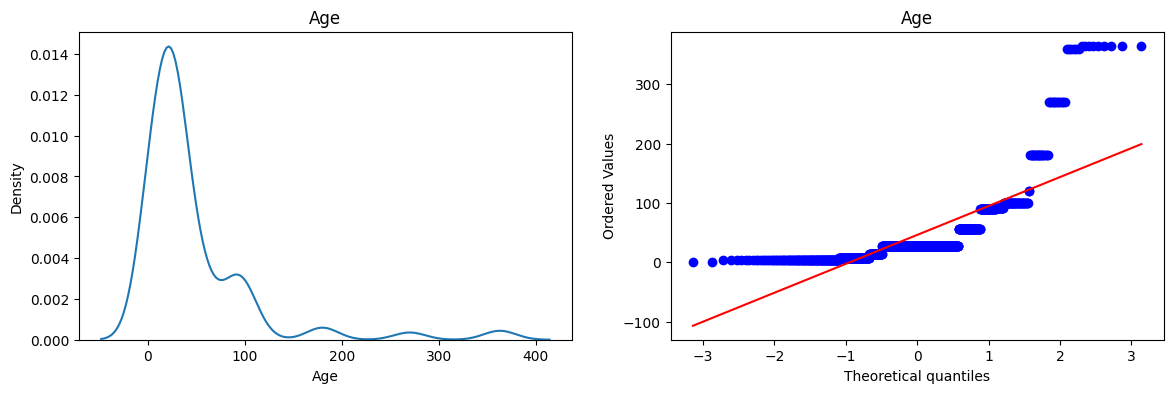

In [12]:
for col in X_train.columns:
    plt.figure(figsize=(14,4))

    plt.subplot(1, 2, 1)
    sns.kdeplot(X_train[col])
    plt.title(col)

    plt.subplot(1, 2, 2)
    stats.probplot(X_train[col], dist='norm', plot=plt)
    plt.title(col)


plt.show()

## Predicting without PowerTransformer

In [13]:
lr = LinearRegression()

In [14]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
y_pred = lr.predict(X_test)

In [16]:
r2_score(y_test, y_pred)

0.6573544964487199

In [17]:
print(np.mean(cross_val_score(lr, X, y, scoring='r2')))

0.4609940491662866


## Predicting using Box-Cox

In [18]:
## The default method of PowerTransformer is 'yeo-johnson'
pt =  PowerTransformer(method='box-cox')

In [19]:
X_train_transformed = pt.fit_transform(X_train+00000.1)
X_test_transformed = pt.transform(X_test+00000.1)

In [20]:
lr = LinearRegression()

In [21]:
lr.fit(X_train_transformed, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
pd.DataFrame({'col': X_train.columns, 'Box-Cox Lambda': pt.lambdas_})

,col,Box-Cox Lambda
0,Cement,0.173368
1,Blast Furnace Slag,0.064544
2,Fly Ash,-0.078168
3,Water,0.827866
4,Superplasticizer,0.270236
5,Coarse Aggregate,1.094552
6,Fine Aggregate,1.943788
7,Age,0.054346


In [23]:
y_pred = lr.predict(X_test_transformed)

In [24]:
r2_score(y_test, y_pred)

0.79540693168621

In [25]:
# Validating with cross val score
pt = PowerTransformer(method='box-cox')
X_transformed = pt.fit_transform(X+00000.1)

lr = LinearRegression()

print('LR CVS is ', np.mean(cross_val_score(lr, X_transformed, y, scoring='r2')))

LR CVS is  0.6737297873391774


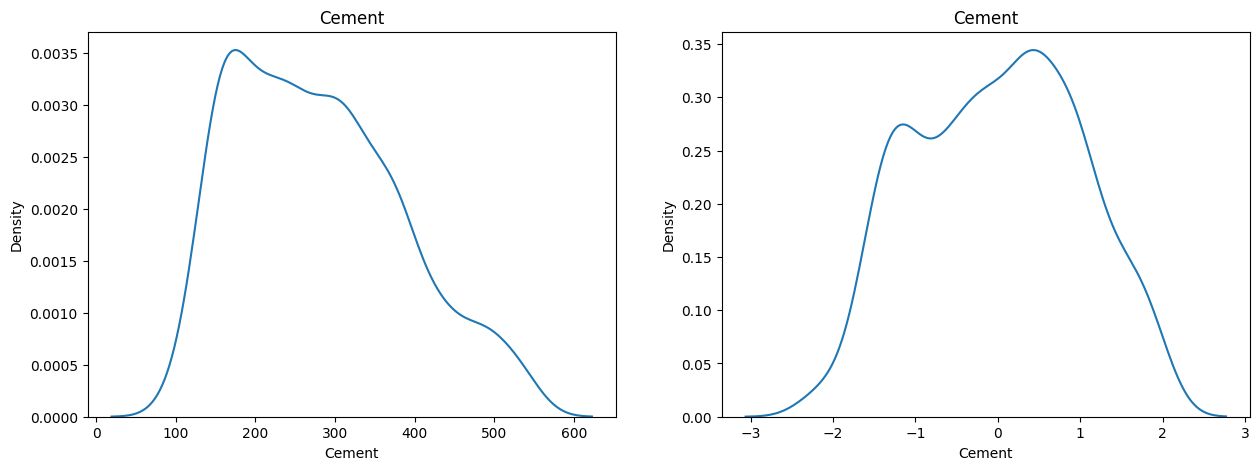

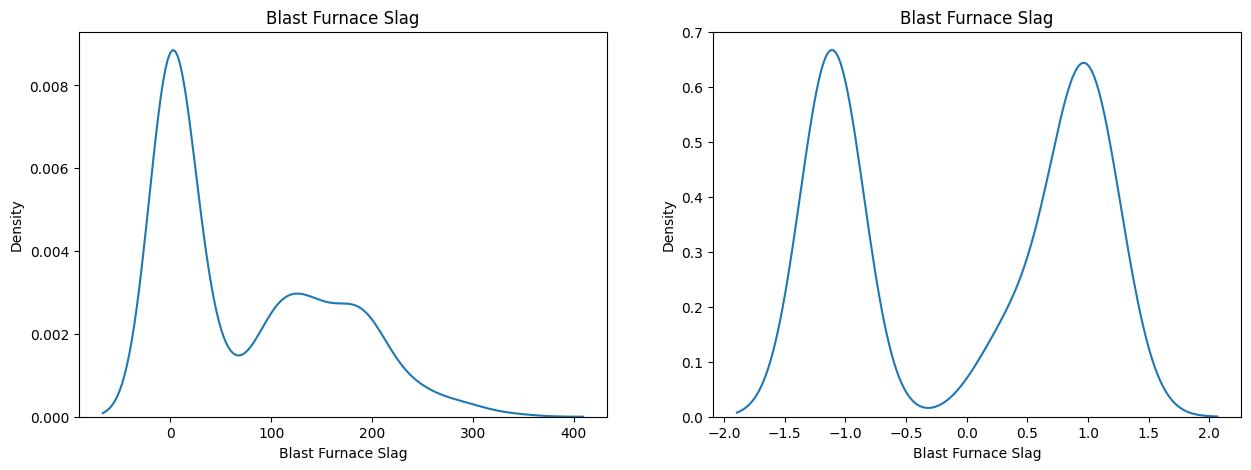

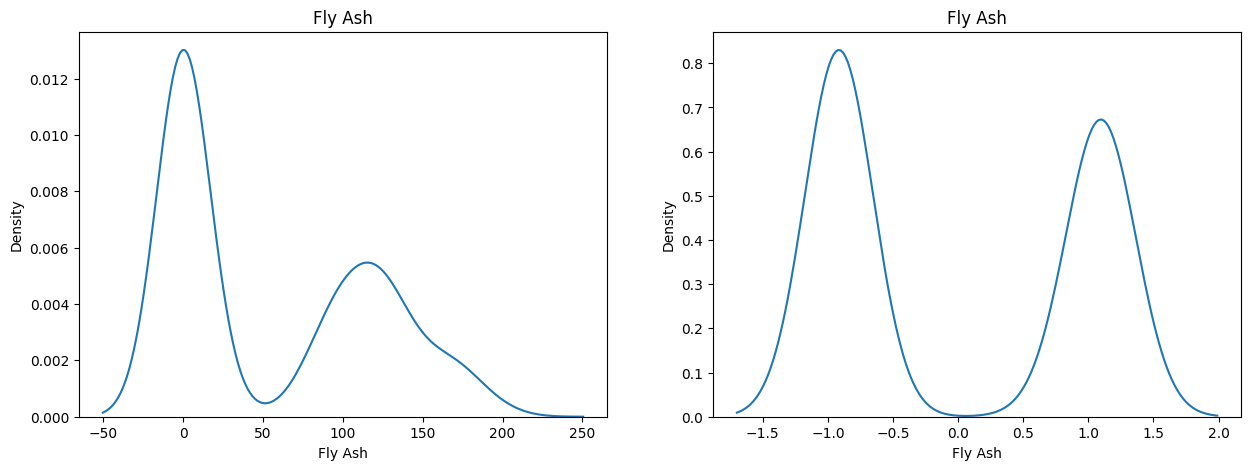

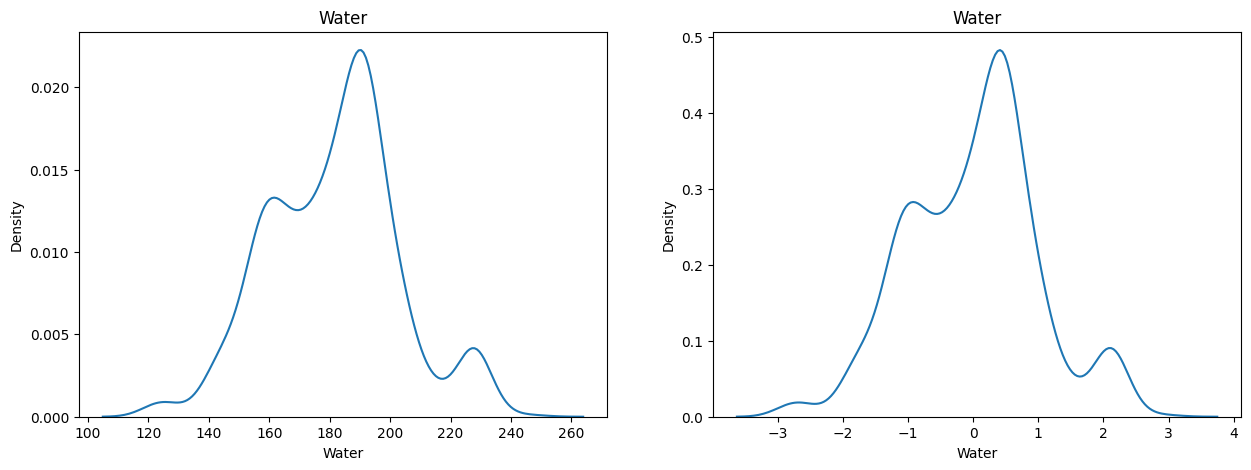

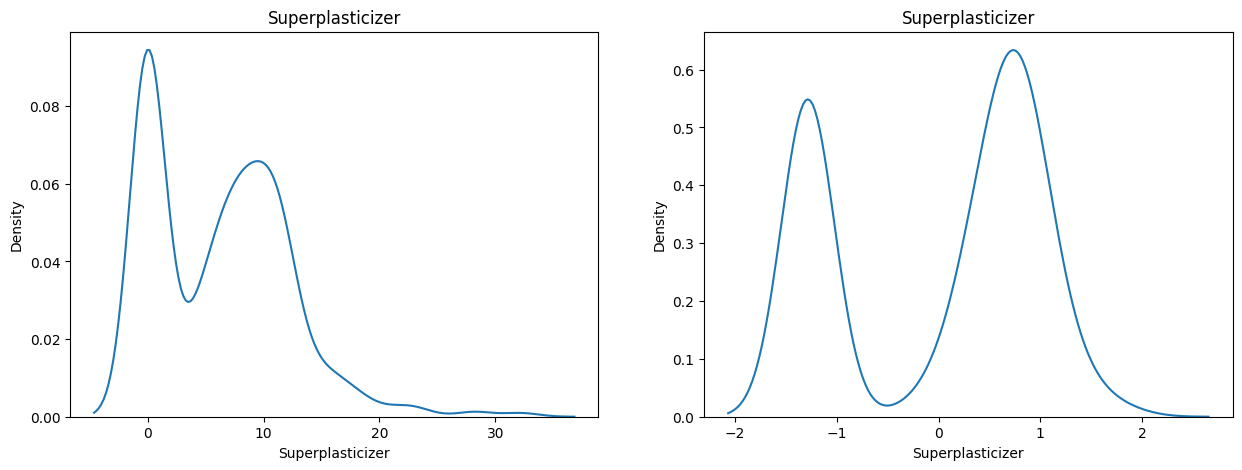

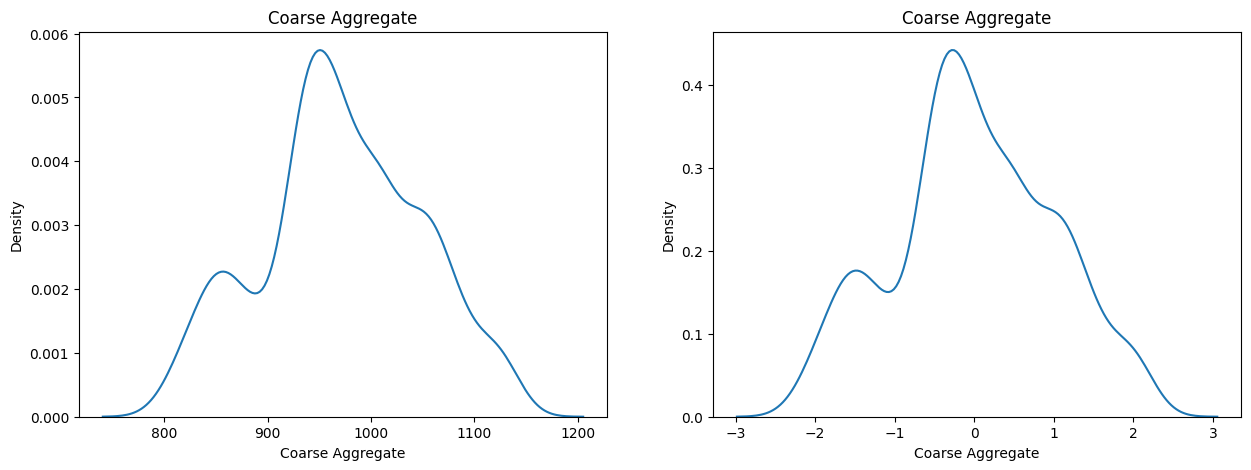

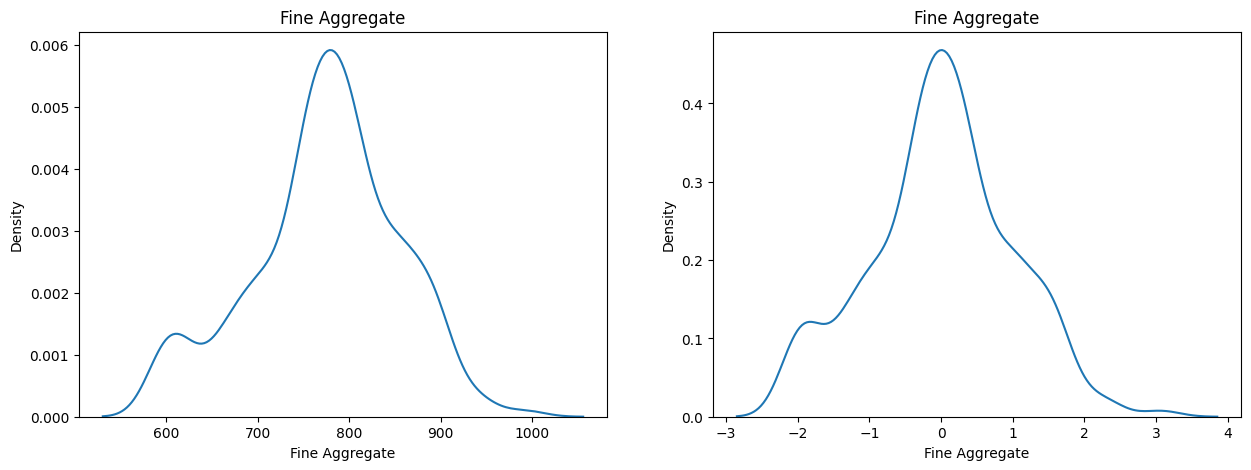

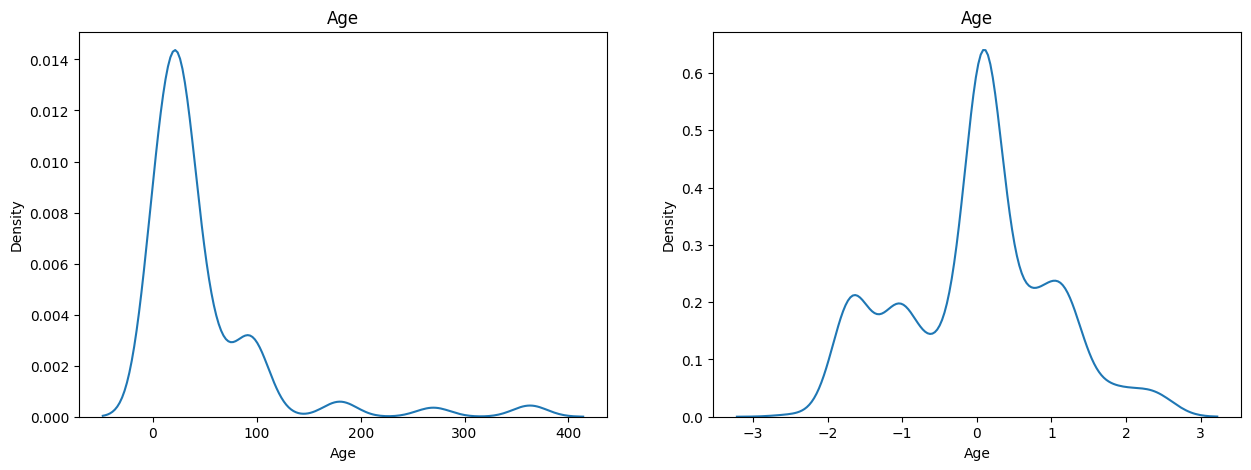

In [26]:
X_train_transformed = pd.DataFrame(X_train_transformed, columns=X_train.columns)


for col in X_train_transformed.columns:
    plt.figure(figsize=(15,5))
    
    plt.subplot(1,2,1)
    sns.kdeplot(X_train[col])
    plt.title(col)

    plt.subplot(1,2,2)
    sns.kdeplot(X_train_transformed[col])
    plt.title(col)

plt.show()

## Predicting using yeo-johnson

In [27]:
## The default method of PowerTransformer is 'yeo-johnson'

pt1 = PowerTransformer()

In [28]:
X_train_transformed1 = pt1.fit_transform(X_train)
X_test_transformed1 = pt1.transform(X_test)

In [29]:
pd.DataFrame({'col': X_train.columns, 'yeo-johnson': pt1.lambdas_})

,col,yeo-johnson
0,Cement,0.170901
1,Blast Furnace Slag,0.050077
2,Fly Ash,-0.121285
3,Water,0.826950
4,Superplasticizer,0.286692
5,Coarse Aggregate,1.094717
6,Fine Aggregate,1.944954
7,Age,0.012692


In [30]:
lr1 = LinearRegression()

lr1.fit(X_train_transformed1, y_train)
y_pred = lr1.predict(X_test_transformed1)

r2_score(y_test, y_pred)

0.802317679338809

In [31]:
# Validating with cross val score
pt = PowerTransformer()
X_transformed = pt.fit_transform(X)

lr = LinearRegression()

print('LR CVS is ', np.mean(cross_val_score(lr, X_transformed, y, scoring='r2')))

LR CVS is  0.6834625130236816


In [32]:
pd.DataFrame({'col': X_train.columns, 'Box-Cox lambda': pt.lambdas_, 'yeo-johnson lambda': pt1.lambdas_})

,col,Box-Cox lambda,yeo-johnson lambda
0,Cement,0.169544,0.170901
1,Blast Furnace Slag,0.016633,0.050077
2,Fly Ash,-0.136480,-0.121285
3,Water,0.808438,0.826950
4,Superplasticizer,0.264160,0.286692
5,Coarse Aggregate,1.129395,1.094717
6,Fine Aggregate,1.830764,1.944954
7,Age,0.001771,0.012692


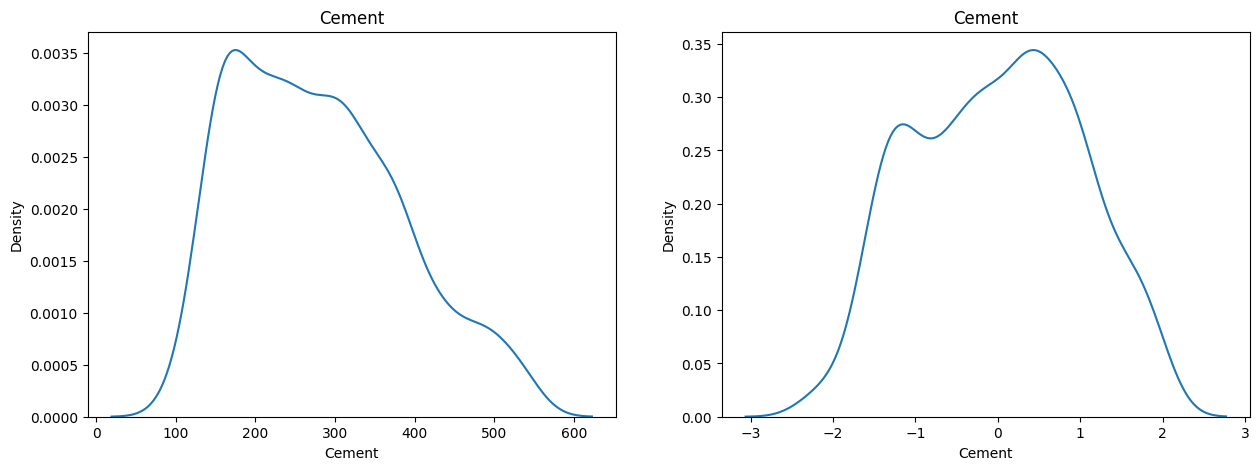

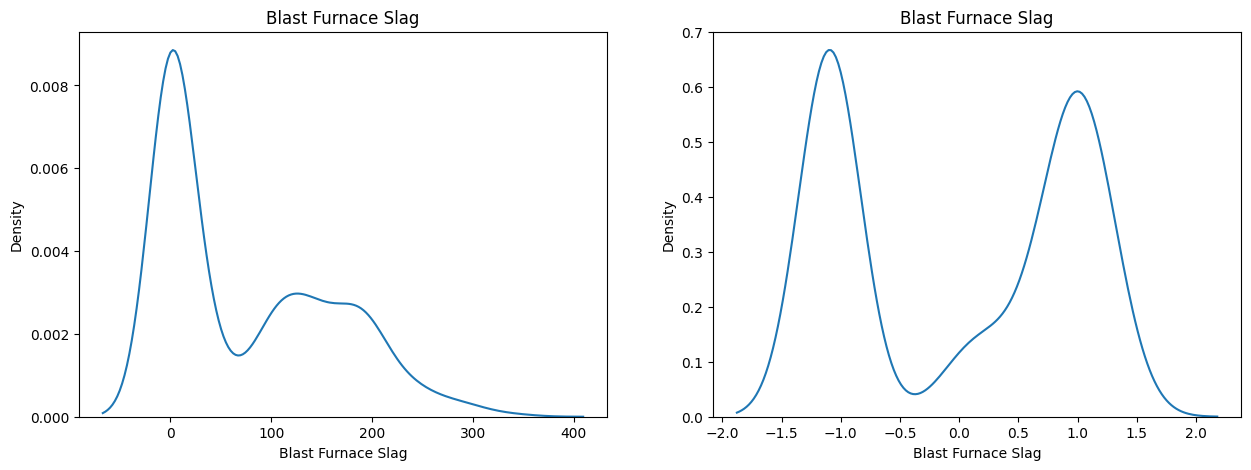

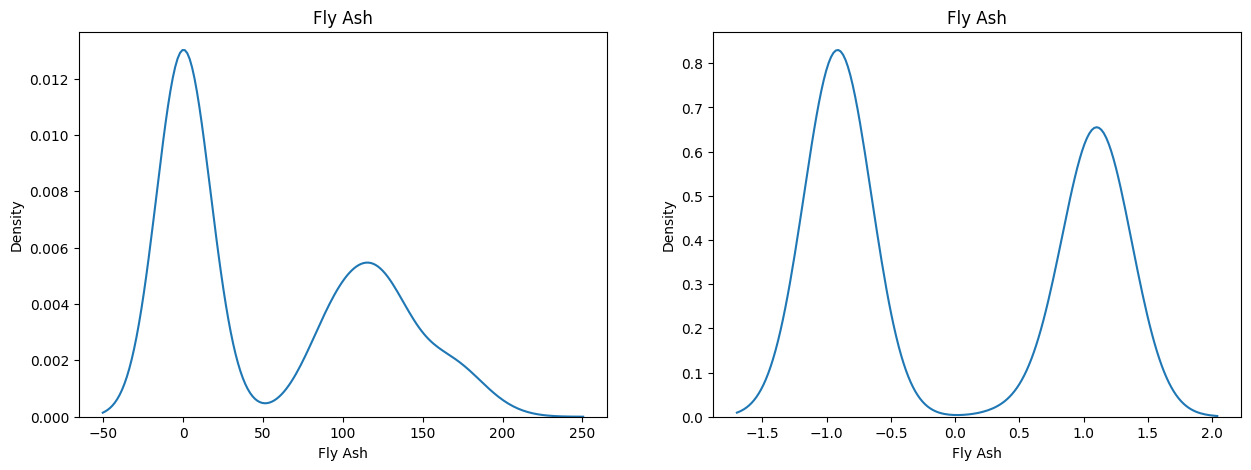

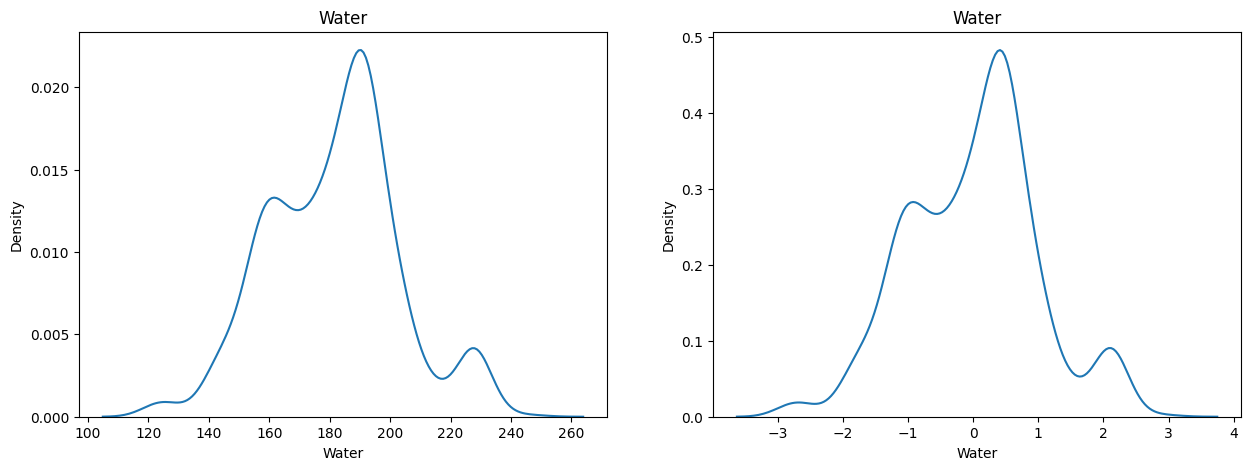

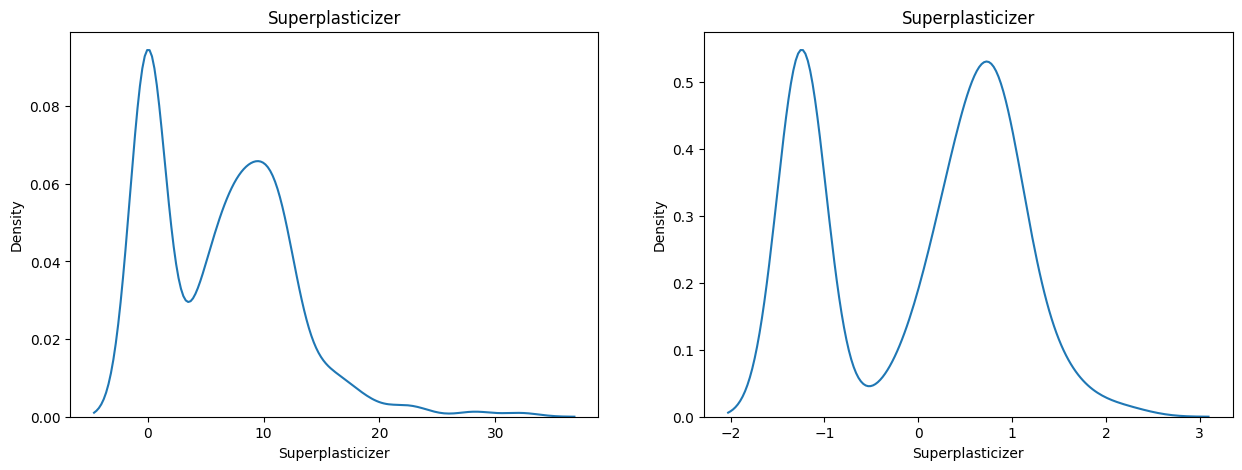

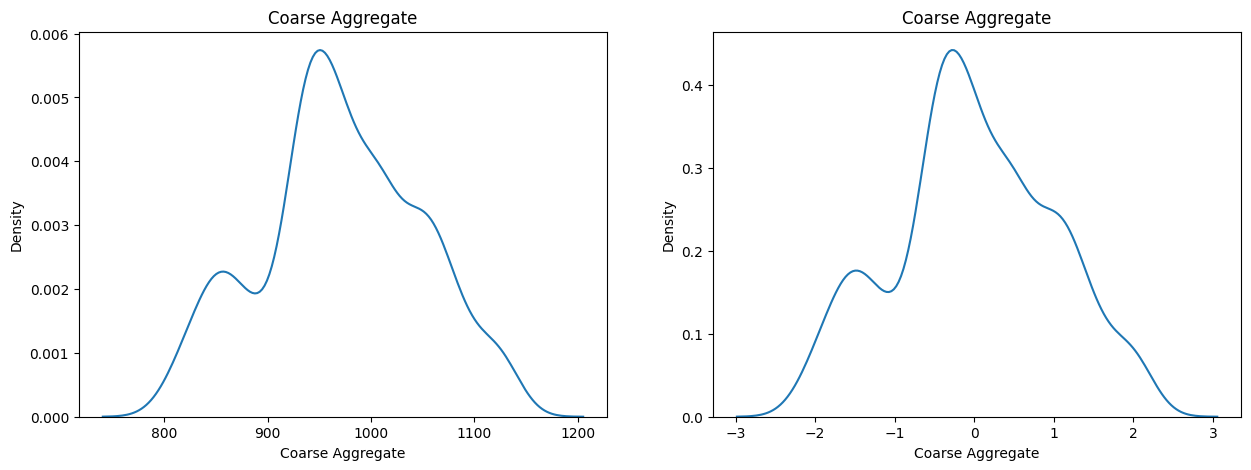

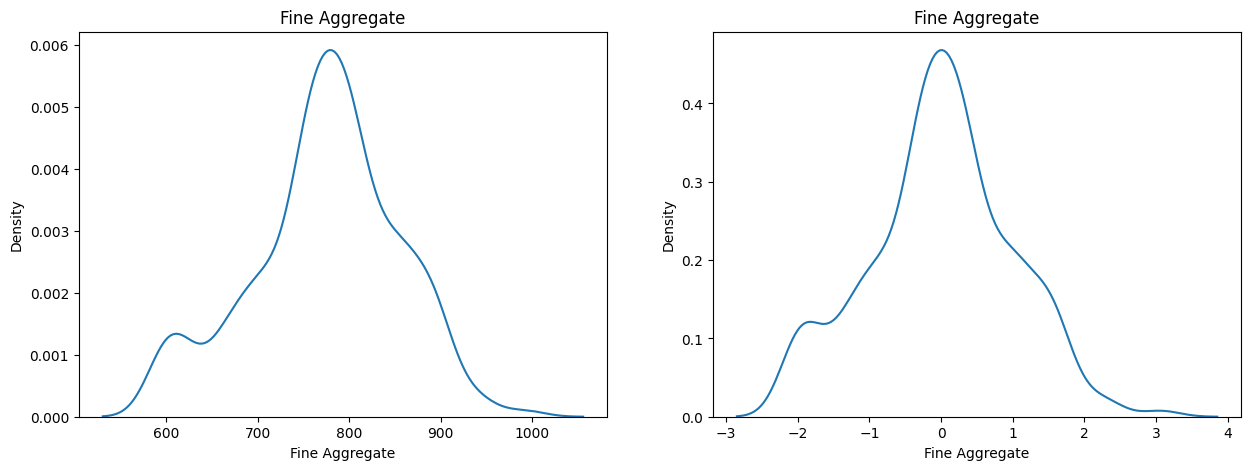

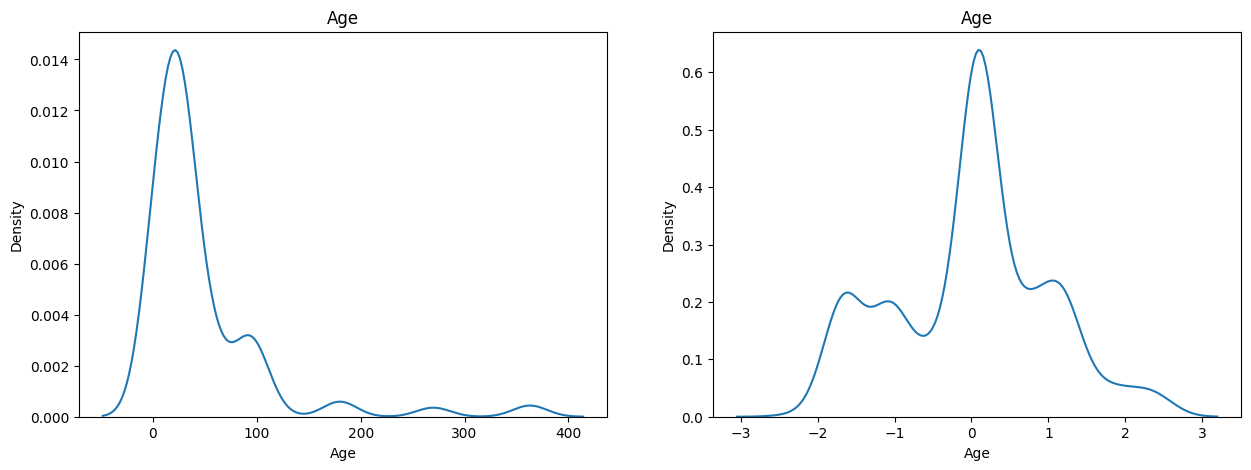

In [33]:
X_train_transformed1=pd.DataFrame(X_train_transformed1, columns=X_train.columns)

for col in X_train_transformed1.columns:
    plt.figure(figsize=(15,5))
    
    plt.subplot(1,2,1)
    sns.kdeplot(X_train[col])
    plt.title(col)

    plt.subplot(1,2,2)
    sns.kdeplot(X_train_transformed1[col])
    plt.title(col)

plt.show()

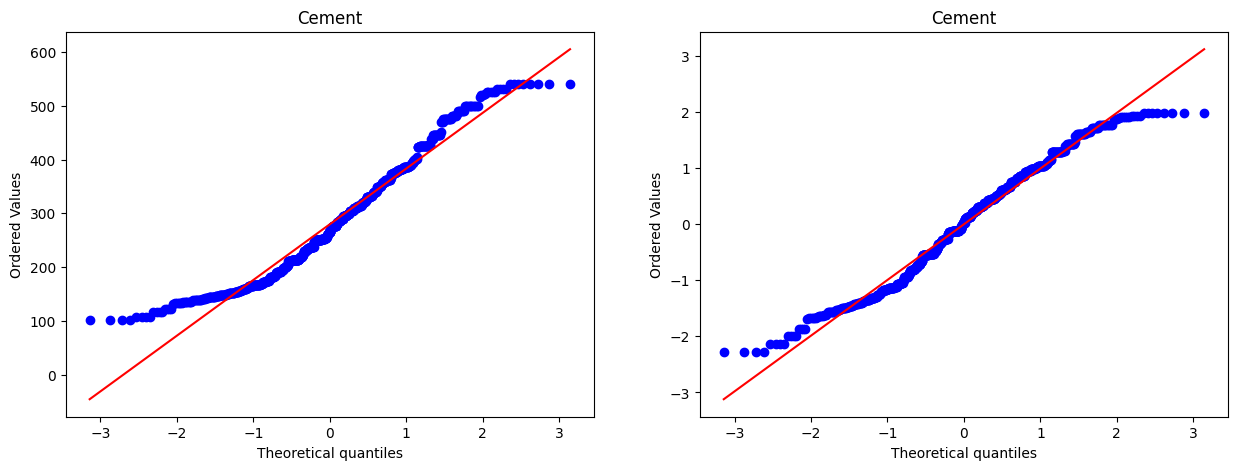

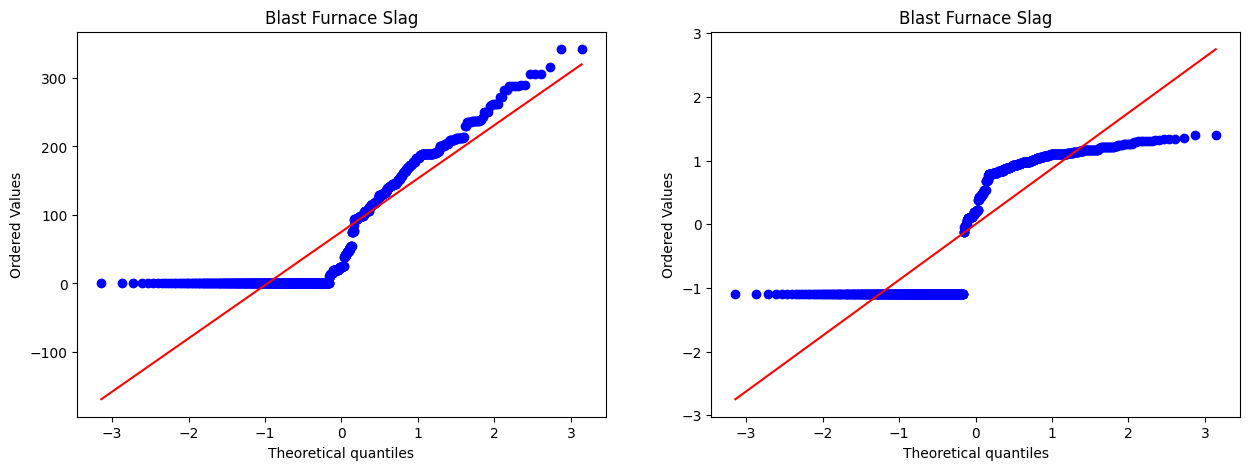

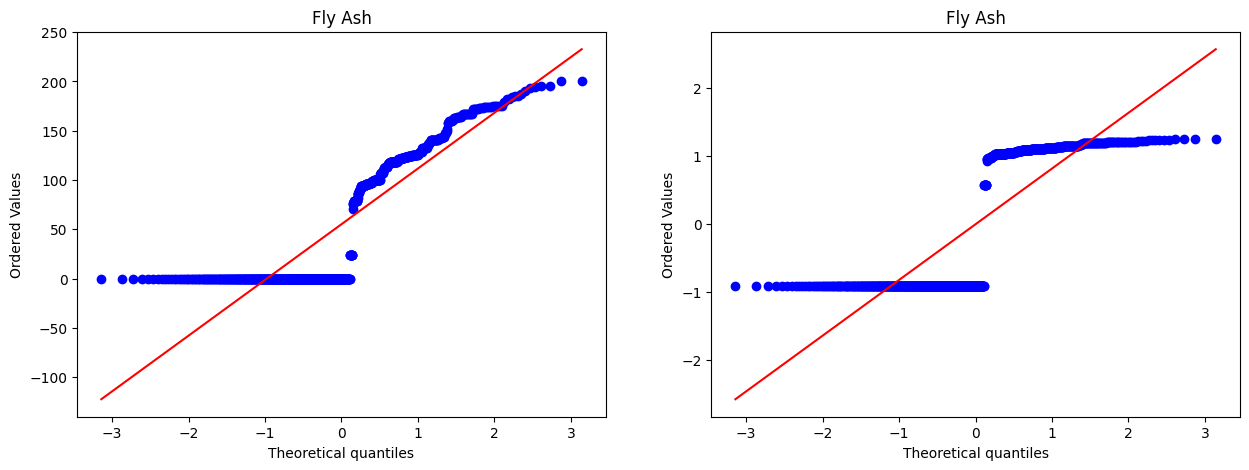

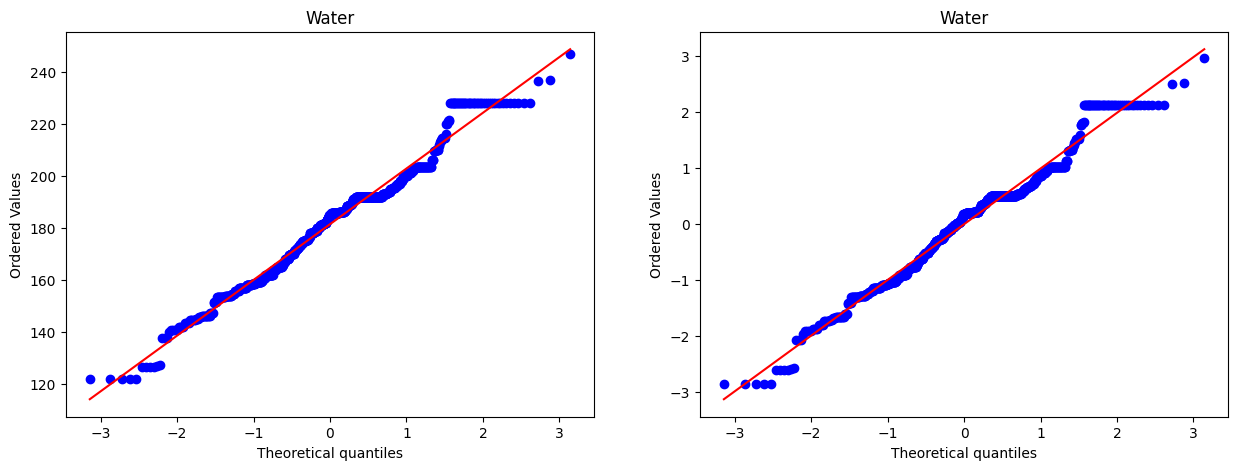

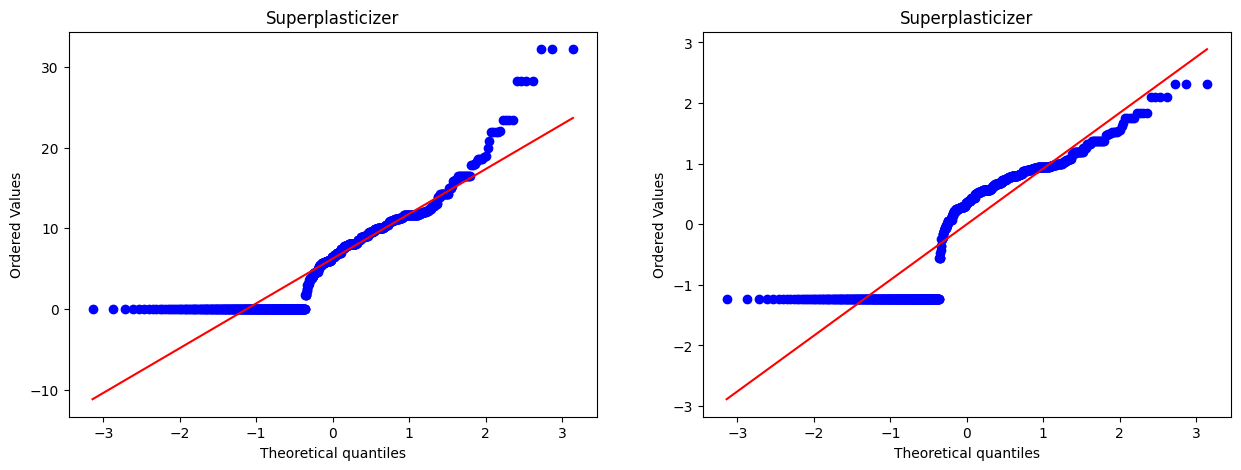

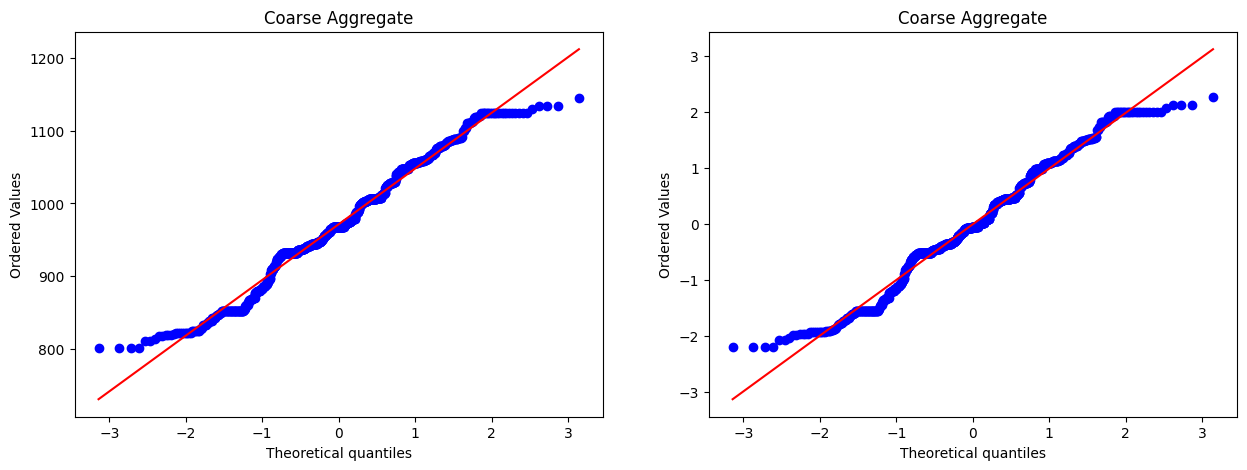

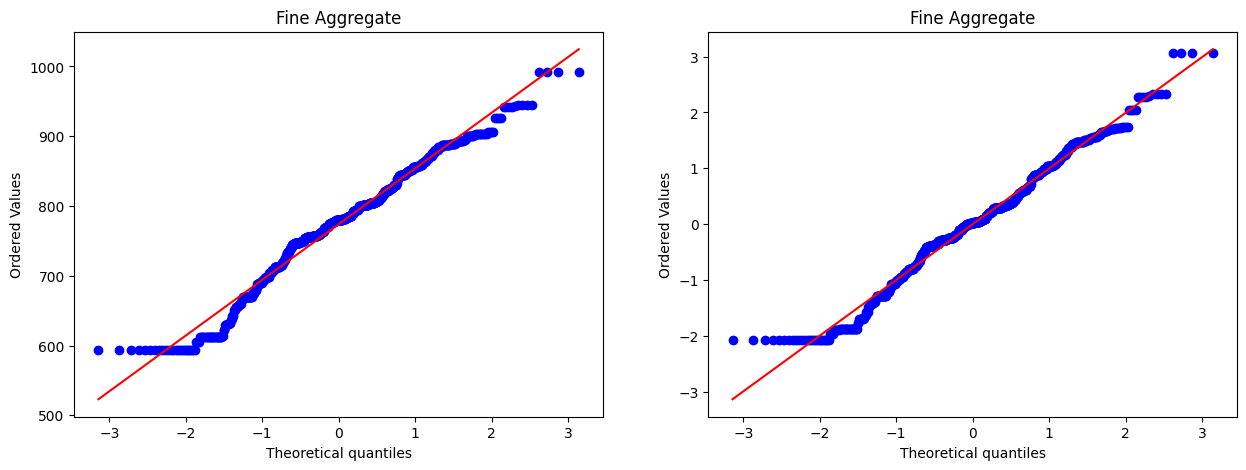

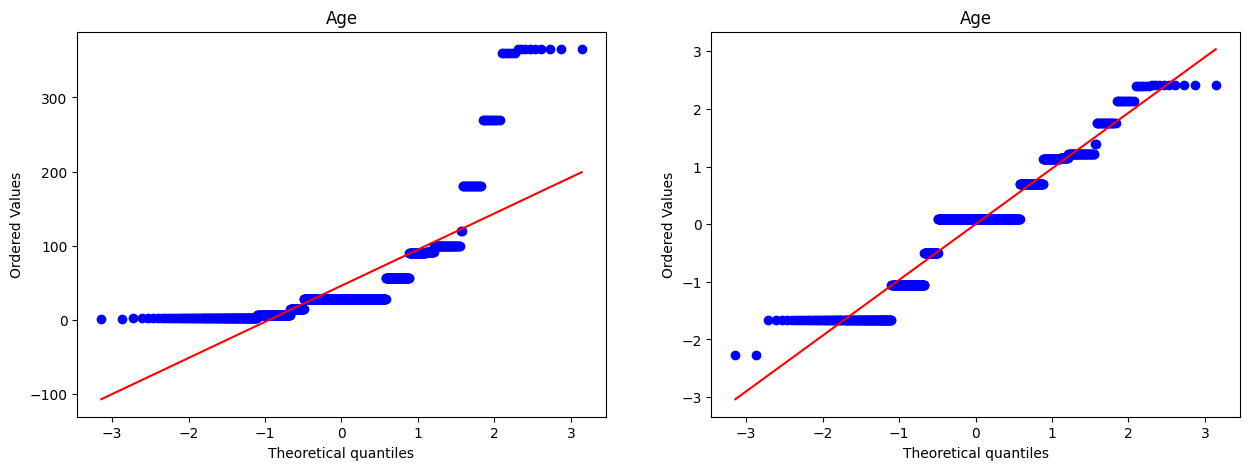

In [35]:
for col in X_train_transformed1.columns:
    plt.figure(figsize=(15,5))
    
    plt.subplot(1,2,1)
    stats.probplot(X_train[col], dist='norm', plot=plt)
    plt.title(col)

    plt.subplot(1,2,2)
    stats.probplot(X_train_transformed1[col], dist='norm', plot=plt)
    plt.title(col)

plt.show()